<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 30px; border-radius: 15px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; text-align: center; box-shadow: 0 10px 20px rgba(0,0,0,0.19), 0 6px 6px rgba(0,0,0,0.23);">
    <div style="font-size: 50px; margin-bottom: 10px;"> 🤖</div>
    <h1 style="margin: 0; font-size: 36px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
        Tox21: Double Deep Q-Network
    </h1>
    <p style="font-size: 18px; margin-top: 5px; font-weight: 300;">
        Molecular decision-making with Double Deep Q-Networks
    </p>
    <p style="font-size: 16px; margin-top: 10px; font-weight: 300; line-height: 1.5;">
    The notebook is structured as follows: <br>
     <strong>Imports</strong> |  <strong>Dataset</strong> |  <strong>GNN Model</strong> |  <strong>Training</strong> |  <strong>Hyperparameter Search</strong> |  <strong>Test</strong>
</p>
</div>

# **Imports**
---

In [1]:
import torch
import os
import numpy as np
import random
from src.DDQN.utils import set_seed
from src.DDQN.config import AGENT_PATH, EPOCHS_AGENT, DEVICE, MAX_STEPS, RANDOM_SEED, NODE_FEATURES, HIDDEN_CHANNELS, NUM_CLASSES, DROPOUT, NUM_GLOBAL_FEATURES
set_seed(RANDOM_SEED)
from sklearn.model_selection import train_test_split
from rdkit import Chem, RDLogger
from src.DDQN.env import *
from src.DDQN.train import train_agent
from src.DDQN.evaluate import evaluate_model
from src.DGN.model import Tox21GNN

#from src.DDQN.analysis import analysis
import pandas as pd

from src.DGN.config import MODEL_PATH as GNN_PATH
from src.DDQN.model import DuelingDQN
from src.DDQN.analysis import analysis


RDLogger.DisableLog('rdApp.*') # disable rdkit warnings

# **Dataset**
---

In [2]:

tox21_df=pd.read_csv("datasets/tox21_processed_features.csv")
all_smiles=tox21_df["smiles"].values
train_smiles,temp_smiles = train_test_split(all_smiles, train_size=0.7, test_size=0.3, random_state=RANDOM_SEED)
valid_smiles, test_smiles = train_test_split(temp_smiles,test_size=0.5, random_state=RANDOM_SEED)

print(f"Valid molecules: {len(all_smiles)}")
print(f"RL Agent train set: {len(train_smiles)} molecules")
print(f"RL Agent test set:   {len(test_smiles)} molecules")


Valid molecules: 7823
RL Agent train set: 5476 molecules
RL Agent test set:   1174 molecules


# **DGN** Predictor
---
The pretrained DGN model is uploaded to be used as predictor of toxicity.

In [3]:

print("- initializing GNN Predictor...")

gnn_model = Tox21GNN(
    num_node_features=NODE_FEATURES,                
    hidden_channels=HIDDEN_CHANNELS, 
    num_classes=NUM_CLASSES, 
    dropout=DROPOUT,
    num_global_features=NUM_GLOBAL_FEATURES
)

gnn_model = gnn_model.to(DEVICE)

# upload DGN weights
gnn_model.load_state_dict(torch.load(GNN_PATH, map_location=DEVICE))  
_ = gnn_model.eval()


- initializing GNN Predictor...


# **Environment**
---

We define a reinforcement learning environment where the agent can modify a molecule through atom addition, atom substitution, bond addition, and bond removal. The environment uses a GNN predictor to evaluate toxicity and constructs states from the GNN embedding.

## Action Space 

The chemical action space consists of:

-   Atom addition: add one of $N_\text{atom}$ atom types with single or  double bond.
-   Atom substitution: replace an atom with another type respecting valence.
-   Bond addition: connect two atoms with single or double bond.
-   Bond removal: remove a non-aromatic bond.

A maximum valence constraint ensures chemically valid structures.

## State Representation

The state $s_t$ at step $t$ is given by the flattened embedding of the current molecule from the GNN predictor:
$s_t = \text{flatten}(\text{GNN}(x, \text{edge\_index}, \text{edge\_attr}, \text{global\_features}))$
where $x, \text{edge\_index}, \text{edge\_attr}$ are graph features extracted from the molecule.

## Reward Function

The reward at each step combines multiple contributions:

1.  Step penalty: $r_\text{step} = 
        \begin{cases}
        -0.5 & \text{if } t \le 2 \\
        -1.5 & \text{if } 3 \le t \le 5 \\
        -3.0 & \text{otherwise}
        \end{cases}$

2.  Invalid action penalty: $r_\text{invalid} = -2.0$
3.  Structural penalty (ring breaking):   $r_\text{ring} = -5.0 \quad \text{if NumRings}_{t} < \text{NumRings}_{\text{start}}$
4.  Similarity penalty:  $r_\text{sim} = - w_\text{sim} \cdot \max(0, \text{threshold} - \text{hybrid\_sim})$
5.  Toxicity change reward: $r_\text{tox} = w_\text{tox} \cdot \max(0, \Delta_\text{tox}), \quad \Delta_\text{tox} = (\max P_\text{curr} - \max P_\text{start}) \cdot \text{direction}$

6.  Flip success bonus: $r_\text{flip} =\begin{cases}w_\text{flip} \cdot (\text{hybrid\_sim})^2 + 60 + 2 \cdot (\text{max\_steps} - t) & \text{if flip \& sim} \ge \text{threshold} \\5.0 & \text{if flip \& sim} < \text{threshold} \end{cases}$

The total reward is then: $r_t = r_\text{step} + r_\text{invalid} + r_\text{ring} + r_\text{sim} + r_\text{tox} + r_\text{flip}$


## Episode Termination 

An episode ends when:

-   The agent successfully flips toxicity above the threshold.

-   Maximum steps are reached: $t \ge \text{max\_steps}$.

-   Invalid action or molecule fragmentation occurs.

This configuration of the environment has been reached by manual optimization, combining chemical validity, similarity to the starting molecule, and toxicity goal.


In [4]:

env = MoleculeEnv(gnn_model=gnn_model,
                  threshold=0.6,
                  max_steps=MAX_STEPS,
                  device=DEVICE,
                  w_tox=W_TOX,
                  w_flip=W_FLIP,
                  w_sim_penalty=W_PEN
)
print(f"- initialized Environment")


- initialized Environment


# **DDQN** Agent & Buffer
---

We implement a **Dueling Deep Q-Network (Dueling DQN)** where the network separates **state-value** and **advantage** streams. The Q-values are computed as:

\begin{equation}
Q(s,a) = V(s) + \Big(A(s,a) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s,a') \Big)
\end{equation}

- $V(s)$ = state-value stream, predicting how good it is to be in state \(s\)  
- $A(s,a)$ = advantage stream, estimating the relative importance of each action \(a\)  
- $|\mathcal{A}|$ = number of possible actions  

This decoupling improves learning stability.

---

The **Weighted Replay Buffer** stores transitions $(s, a, r, s', \text{done})$ and samples them according to **priority weights**:

\begin{equation}
w_i = \left( N \cdot P(i) \right)^{-\beta}, \quad 
P(i) = \frac{(|r_i| + \epsilon)^\alpha}{\sum_j (|r_j| + \epsilon)^\alpha}
\end{equation}

- $s, a, r, s', \text{done}$ = state, action, reward, next state, done flag  
- $N$ = total number of transitions in the buffer  
- $\alpha$ = prioritization factor (0 = uniform sampling)  
- $\beta$ = importance-sampling correction factor (annealed from 0.4 → 1.0)  
- $\epsilon$ = small constant to avoid zero probability  
- $w_i$ = normalized weight used in the loss function  

This buffer allows **oversampling important transitions** and ensures **unbiased updates** through importance sampling.


In [5]:

policy_net = DuelingDQN(LATENT_DIM, env.action_space_size, hidden_dim=512)
target_net = DuelingDQN(LATENT_DIM, env.action_space_size, hidden_dim=512)
print("- initialized DDQN networks")


- initialized DDQN networks


# **Train**
---

We train a Double Dueling Deep Q-Network (DDQN) agent using an epsilon-greedy policy. 
At each step, the agent interacts with the environment, stores transitions in a weighted replay buffer, 
and samples mini-batches to update the policy network. 
The Q-learning target is computed using the Double DQN formulation:
\begin{equation}
y_i = r_i + \gamma \, Q_{\theta^T}(s'_i, \arg\max_{a'} Q_\theta(s'_i, a'))
\end{equation}
where:
- $s_i$ = current state of the environment
- $a_i$ = action taken in state $s_i$
- $r_i$ = reward received after taking action $a_i$
- $s'_i$ = next state after the action
- $\gamma$ = discount factor for future rewards
- $Q_\theta$ = policy network estimating Q-values
- $Q_{\theta^T}$ = target network used for stable evaluation
- $\arg\max_{a'} Q_\theta(s'_i, a')$ = action selected by the policy network in the next state


The loss function is a Huber loss weighted by sampling priorities:
\begin{equation}
\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} w_i \, \big( y_i - Q_\theta(s_i, a_i) \big)^2
\end{equation}
where:

- $N$ = batch size sampled from the replay buffer
- $w_i$ = weight of the $i$-th transition, proportional to its importance
- $y_i$ = target Q-value from the Double DQN formulation
- $Q_\theta(s_i, a_i)$ = predicted Q-value for state $s_i$ and action $a_i$


The optimizer used is Adam with gradient clipping. The target network is updated via soft updates, 
and the best-performing agent is saved based on the average episodic reward.


In [6]:

print(f"Starting Training for {EPOCHS_AGENT} episodes...")

"""
trained_agent = train_agent(
    p_model=policy_net,
    t_model=target_net,
    env,
    smiles_list=train_smiles, 
    batch_size=BATCH_SIZE_RL_AGENT, 
    lr=LR_GENERATOR,
    gamma=GAMMA
)


torch.save(trained_agent.state_dict(), AGENT_PATH)
print(f"Agent trained and saved to {AGENT_PATH}")
"""


Starting Training for 3000 episodes...


'\ntrained_agent = train_agent(\n    p_model=policy_net,\n    t_model=target_net,\n    env,\n    smiles_list=train_smiles, \n    batch_size=BATCH_SIZE_RL_AGENT, \n    lr=LR_GENERATOR,\n    gamma=GAMMA\n)\n\n\ntorch.save(trained_agent.state_dict(), AGENT_PATH)\nprint(f"Agent trained and saved to {AGENT_PATH}")\n'

# **Results**
---

In [7]:

print(f"Loading Best Agent from {AGENT_PATH} for evaluation...")
best_agent = DuelingDQN(input_dim=LATENT_DIM, output_dim=env.action_space_size,hidden_dim=512).to(DEVICE)
best_agent.load_state_dict(torch.load(AGENT_PATH))
stats = evaluate_model(best_agent, env, test_smiles, device=DEVICE)


Loading Best Agent from ./weights/DDQN/best_DDQN.pth for evaluation...

--- Starting Evaluation ---

Final Evaluation (1174 mols, 10 attempts/mol):
Strict Success Rate (Flip + Sim>=0.6):  28.28%
Loose Success Rate (Any Flip):          32.71%
------------------------------------------------------------
On Valid counter-factuals:
  - Avg Tanimoto (on Success):          0.684
  - Avg Hybrid Sim (on Success):        0.723
  - Avg Steps (on Success):             1.0
------------------------------------------------------------
Including failures:
  - Avg Tanimoto (All):                 0.533
  - Avg Hybrid Sim (All):               0.576



# **Further Analisy**
---

best_smiles found

CC(C)(CO)C(O)C(=O)NCCC(=O)NCCSSCCNC(=O)CCNC(=O)C(O)C(C)(C)CO+

CC(C)(CO)C(O)C(=O)NCCC(=O)NCCSSCCNC(=O)CCNC(=O)C(O)C(C)(C)CP+

CNC(=O)c1c(I)c(C(=O)NCC(=O)Nc2c(I)c(C(=O)O)c(I)c(C(=O)NCCO)c2I)c(I)c(N(C)C(C)=O)c1I+

CNC(=O)c1c(S)c(N(C)C(C)=O)c(I)c(C(=O)NCC(=O)Nc2c(I)c(C(=O)O)c(I)c(C(=O)NCCO)c2I)c1I+

Generato report visuale: Diff_Analysis_1_try.html
Hybrid_similarity of Streptozocina(originale) 0.9146142992973327
Hybrid_similarity Tilosina (Origine) 0.9346017826687205


c:\Users\Emilio\Desktop\Magistrale\RL\RL_project\src\DDQN\analysis.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, y='Azione Rilevata', x='Count', palette='Set2', orient='h')


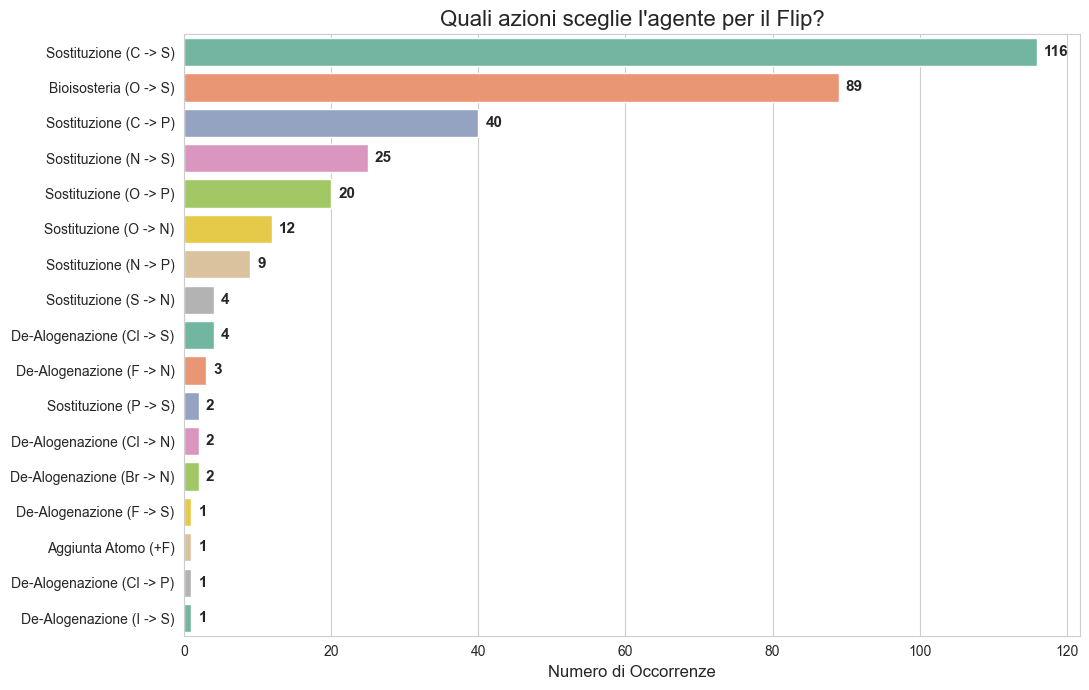

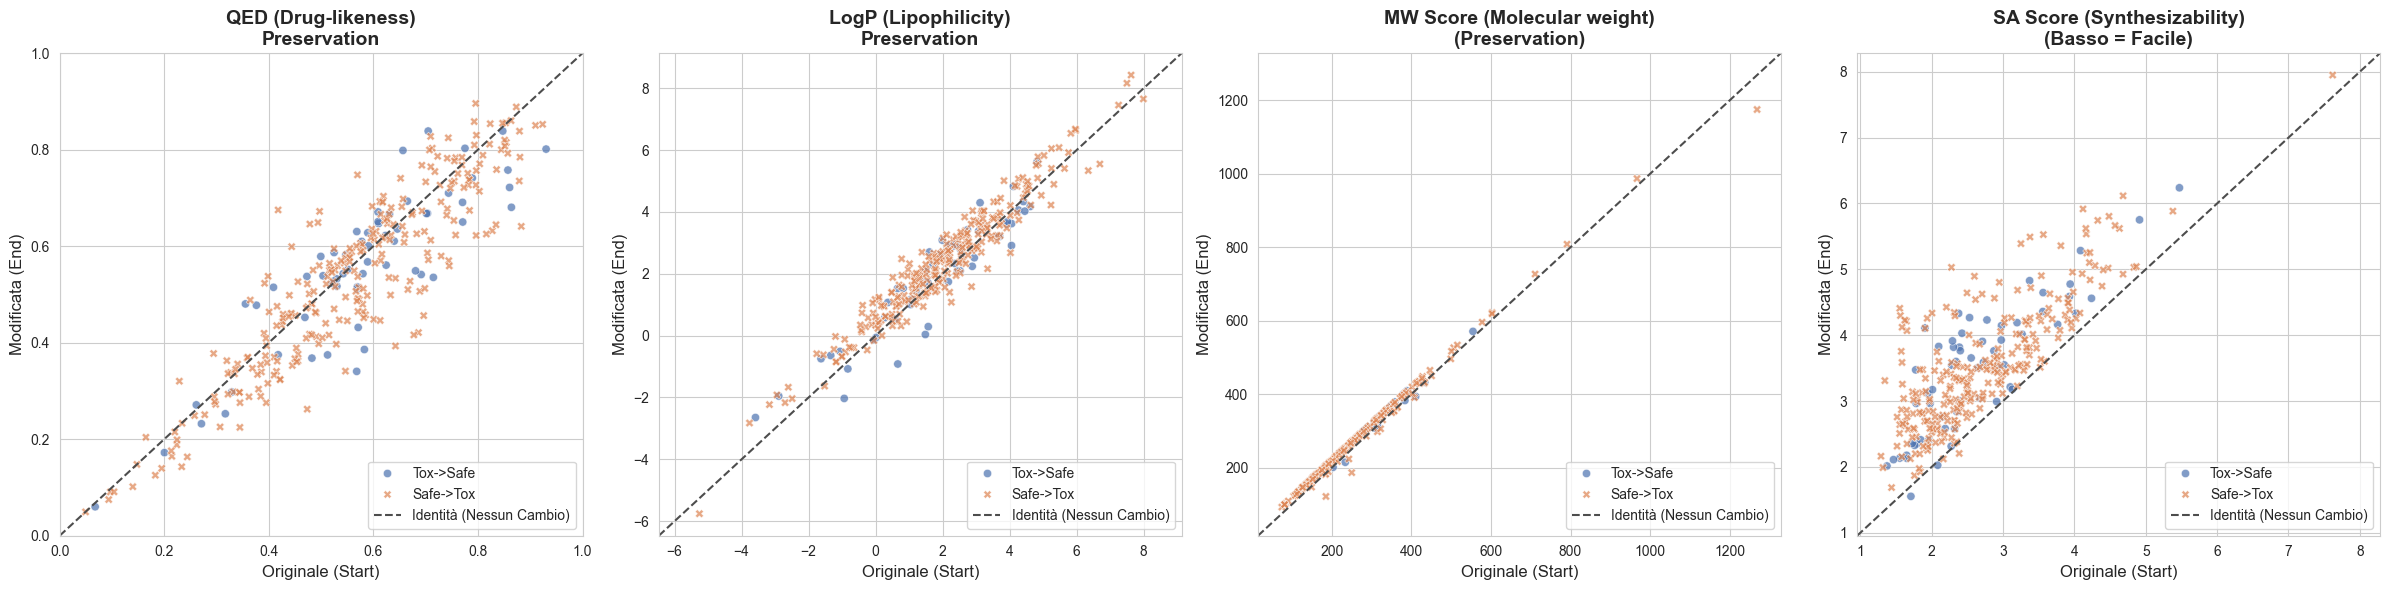


--- ANALISI PROPRIETÀ DRUG-LIKE ---
Totale transizioni analizzate: 332
Molecole con crollo QED (>0.1): 49 / 332 (14.8%)
Molecole diventate difficili da sintetizzare (Delta SA > 1.0): 103 (31.0%)


c:\Users\Emilio\Desktop\Magistrale\RL\RL_project\src\DDQN\analysis.py:576: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Type', order=order, palette='Set2', orient='h')


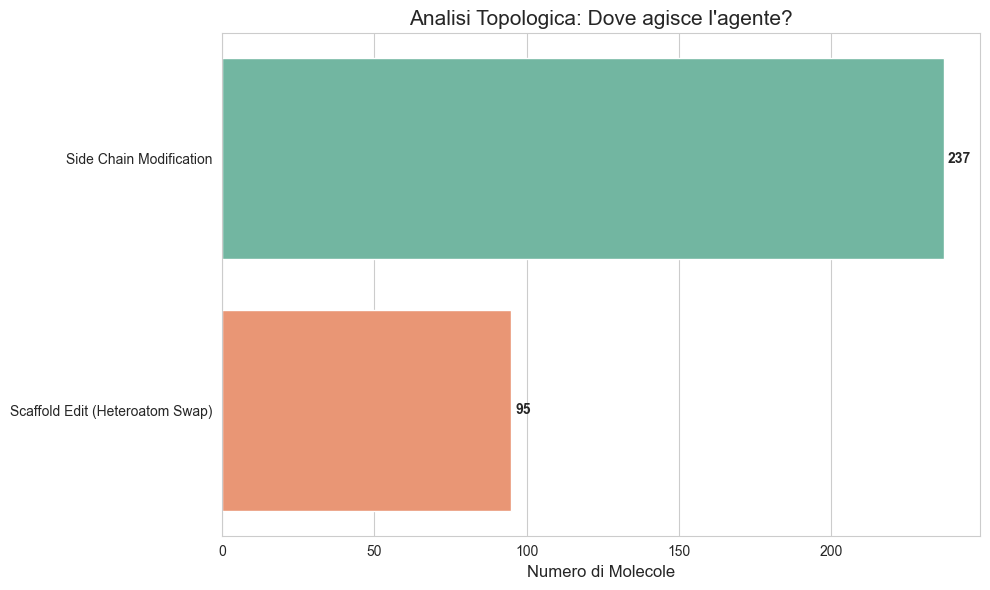


--- SCAFFOLD ANALYSIS REPORT ---
Totale Modifiche: 332
Side Chain Mods (Scaffold Preservato): 237 (71.4%)
Core Mods (Scaffold Modificato):       95 (28.6%)


In [ ]:
analysis(stats=stats)